In [1]:
#Importing required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
match_df = pd.read_csv("matches.csv")
delivery_df = pd.read_csv("deliveries.csv")

In [3]:
# match dataframe
match_df.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
# delivery dataframe
delivery_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
print(match_df.isnull().sum())
print(delivery_df.isnull().sum())

id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
dtype:

In [6]:
match_df = match_df[['id', 'city', 'team1', 'team2', 'winner']]
delivery_df = delivery_df[['match_id', 'inning', 'batting_team', 'bowling_team', 'total_runs']]
print(match_df.head())
print(delivery_df.head())


   id       city                        team1                        team2  \
0   1  Hyderabad          Sunrisers Hyderabad  Royal Challengers Bangalore   
1   2       Pune               Mumbai Indians       Rising Pune Supergiant   
2   3     Rajkot                Gujarat Lions        Kolkata Knight Riders   
3   4     Indore       Rising Pune Supergiant              Kings XI Punjab   
4   5  Bangalore  Royal Challengers Bangalore             Delhi Daredevils   

                        winner  
0          Sunrisers Hyderabad  
1       Rising Pune Supergiant  
2        Kolkata Knight Riders  
3              Kings XI Punjab  
4  Royal Challengers Bangalore  
   match_id  inning         batting_team                 bowling_team  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
3         1       1  Sunrisers Hyderabad 

In [7]:
# Merging the datasets on match_id
merged_df = delivery_df.merge(match_df, left_on='match_id', right_on='id', how='inner')

# Dropping one of the duplicate match ID columns
merged_df.drop(columns=['id'], inplace=True)

# Display the first few rows to verify
print(merged_df.head())


   match_id  inning         batting_team                 bowling_team  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   

   total_runs       city                team1                        team2  \
0           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
1           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
2           4  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
3           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
4           2  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   

                winner  
0  Sunrisers Hyderabad  
1  Sunrisers Hyderabad  
2  Sunrisers Hyde

In [8]:
# Merging the datasets on match_id
merged_df = delivery_df.merge(match_df, left_on='match_id', right_on='id', how='inner')

# Dropping one of the duplicate match ID columns
merged_df.drop(columns=['id'], inplace=True)

# Display the first few rows to verify
print(merged_df.head())


   match_id  inning         batting_team                 bowling_team  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   

   total_runs       city                team1                        team2  \
0           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
1           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
2           4  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
3           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
4           2  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   

                winner  
0  Sunrisers Hyderabad  
1  Sunrisers Hyderabad  
2  Sunrisers Hyde

In [9]:
#Check for Missing Values
print(merged_df.isnull().sum())


match_id           0
inning             0
batting_team       0
bowling_team       0
total_runs         0
city            1700
team1              0
team2              0
winner           372
dtype: int64


In [10]:
#fill the missing value
merged_df = merged_df.assign(
    city=merged_df['city'].fillna(merged_df['city'].mode()[0]),
    winner=merged_df['winner'].fillna('No Result')
)



In [11]:
#now agian check the missing values
print(merged_df.isnull().sum())


match_id        0
inning          0
batting_team    0
bowling_team    0
total_runs      0
city            0
team1           0
team2           0
winner          0
dtype: int64


In [12]:
#Check Data Types
print(merged_df.dtypes)


match_id         int64
inning           int64
batting_team    object
bowling_team    object
total_runs       int64
city            object
team1           object
team2           object
winner          object
dtype: object


In [13]:
#Check Unique Values in Key Columns
print(merged_df['team1'].unique())
print(merged_df['team2'].unique())
print(merged_df['winner'].unique())
print(merged_df['batting_team'].unique())
print(merged_df['bowling_team'].unique())


['Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Royal Challengers Bangalore'
 'Kolkata Knight Riders' 'Delhi Daredevils' 'Kings XI Punjab'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Rising Pune Supergiants'
 'Delhi Capitals']
['Royal Challengers Bangalore' 'Rising Pune Supergiant'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Delhi Daredevils'
 'Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions' 'Rajasthan Royals'
 'Chennai Super Kings' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Rising Pune Supergiants' 'Delhi Capitals']
['Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Kolkata Knight Riders'
 'Kings XI Punjab' 'Royal Challengers Bangalore' 'Mumbai Indians'
 'Delhi Daredevils' 'Gujarat Lions' 'Chennai Super Kings'
 'Rajasthan Royals' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'No Result' 'Rising Pune Supergiants'
 'Delhi Capitals']
['Sunrisers Hyderabad' 'Royal Ch

In [14]:
#merged same new and old names
merged_df.replace({'Delhi Daredevils': 'Delhi Capitals'}, inplace=True)


In [15]:
#again check same name
print(merged_df['team1'].unique())
print(merged_df['team2'].unique())
print(merged_df['winner'].unique())
print(merged_df['batting_team'].unique())
print(merged_df['bowling_team'].unique())


['Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Royal Challengers Bangalore'
 'Kolkata Knight Riders' 'Delhi Capitals' 'Kings XI Punjab'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala' 'Pune Warriors' 'Rising Pune Supergiants']
['Royal Challengers Bangalore' 'Rising Pune Supergiant'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Delhi Capitals'
 'Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions' 'Rajasthan Royals'
 'Chennai Super Kings' 'Deccan Chargers' 'Pune Warriors'
 'Kochi Tuskers Kerala' 'Rising Pune Supergiants']
['Sunrisers Hyderabad' 'Rising Pune Supergiant' 'Kolkata Knight Riders'
 'Kings XI Punjab' 'Royal Challengers Bangalore' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Lions' 'Chennai Super Kings' 'Rajasthan Royals'
 'Deccan Chargers' 'Pune Warriors' 'Kochi Tuskers Kerala' 'No Result'
 'Rising Pune Supergiants']
['Sunrisers Hyderabad' 'Royal Challengers Bangalore' 'Mumbai Indians'
 'Rising Pune Supergi

In [16]:
#chcks the first few rows
print(merged_df.head())


   match_id  inning         batting_team                 bowling_team  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore   

   total_runs       city                team1                        team2  \
0           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
1           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
2           4  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
3           0  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   
4           2  Hyderabad  Sunrisers Hyderabad  Royal Challengers Bangalore   

                winner  
0  Sunrisers Hyderabad  
1  Sunrisers Hyderabad  
2  Sunrisers Hyde

In [17]:
#save the final cleaned datset
merged_df.to_csv('final_dataset.csv', index=False)


C:\Users\Aman Gupta\AppData\Local\Temp\ipykernel_19024\3351881485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_matches.index, y=team_matches.values, palette='coolwarm')


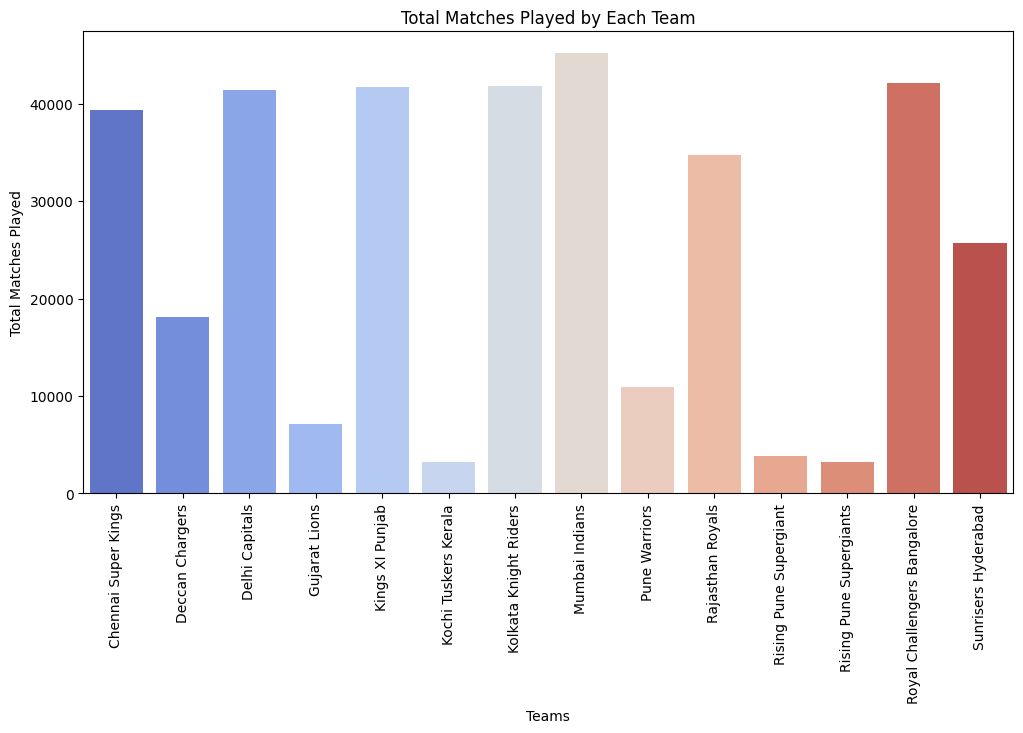

In [18]:
#Total Matches Played by Each Team

team_matches = merged_df['team1'].value_counts() + merged_df['team2'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=team_matches.index, y=team_matches.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.xlabel("Teams")
plt.ylabel("Total Matches Played")
plt.title("Total Matches Played by Each Team")
plt.show()


C:\Users\Aman Gupta\AppData\Local\Temp\ipykernel_19024\268895012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')


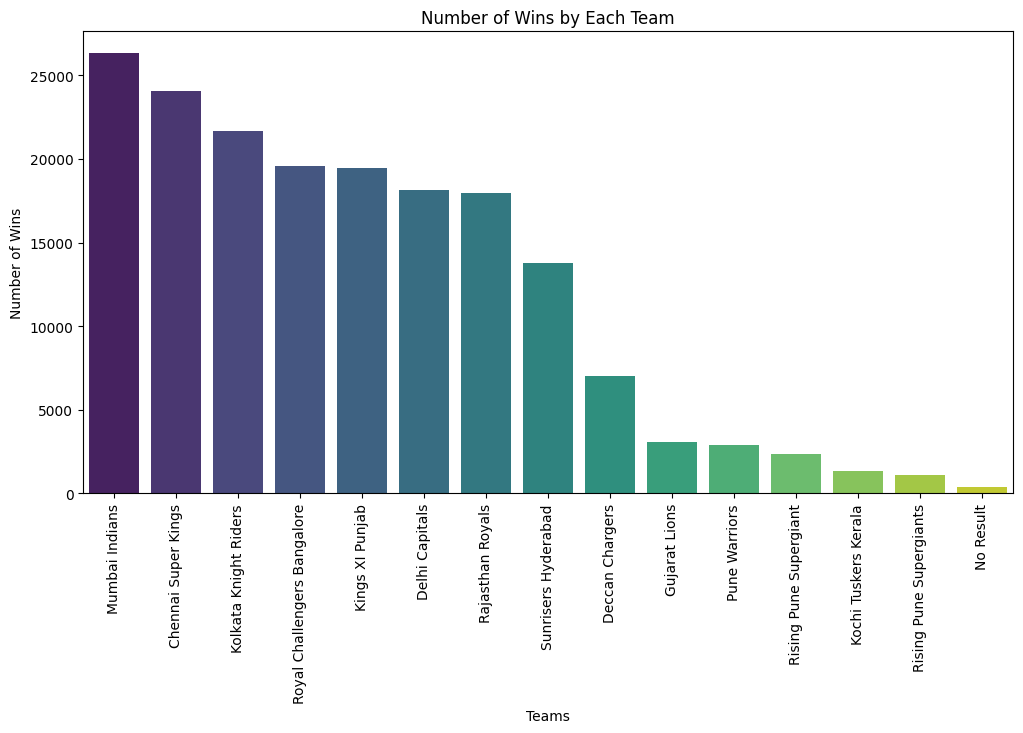

In [19]:
#Number of Wins by Each Team
winner_counts = merged_df['winner'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel("Teams")
plt.ylabel("Number of Wins")
plt.title("Number of Wins by Each Team")
plt.show()


C:\Users\Aman Gupta\AppData\Local\Temp\ipykernel_19024\4051833552.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_runs.index, y=team_runs.values, palette='magma')


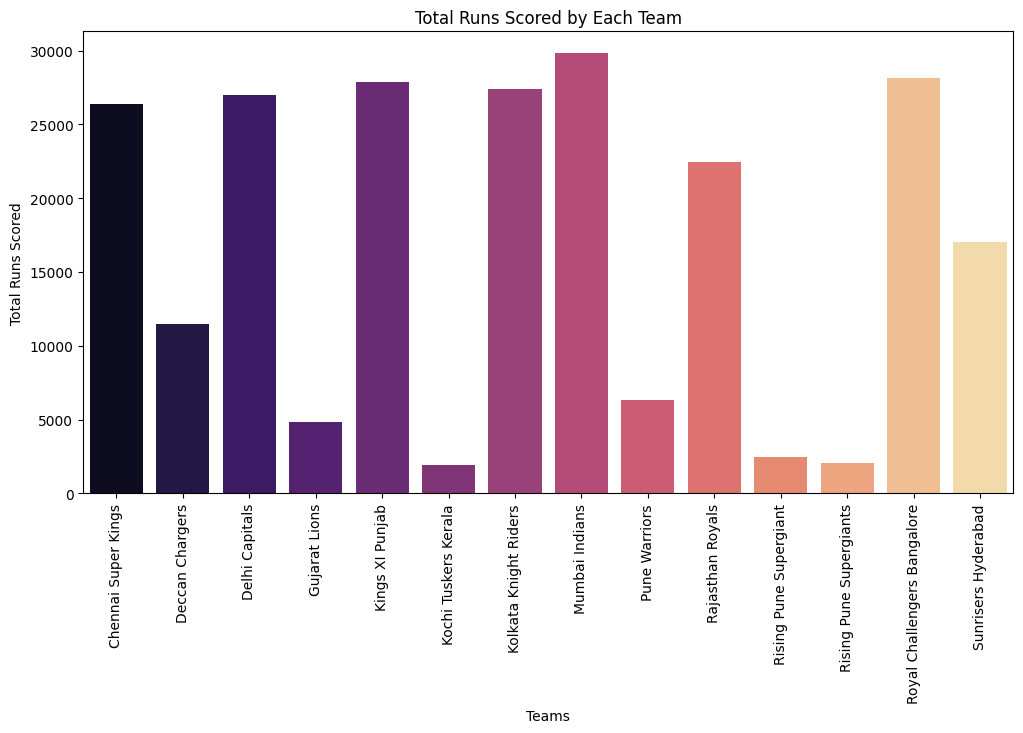

In [20]:
#Total Runs Scored by Each Team
team_runs = merged_df.groupby('batting_team')['total_runs'].sum()
plt.figure(figsize=(12,6))
sns.barplot(x=team_runs.index, y=team_runs.values, palette='magma')
plt.xticks(rotation=90)
plt.xlabel("Teams")
plt.ylabel("Total Runs Scored")
plt.title("Total Runs Scored by Each Team")
plt.show()


C:\Users\Aman Gupta\AppData\Local\Temp\ipykernel_19024\2293996118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_matches.index, y=city_matches.values, palette='plasma')


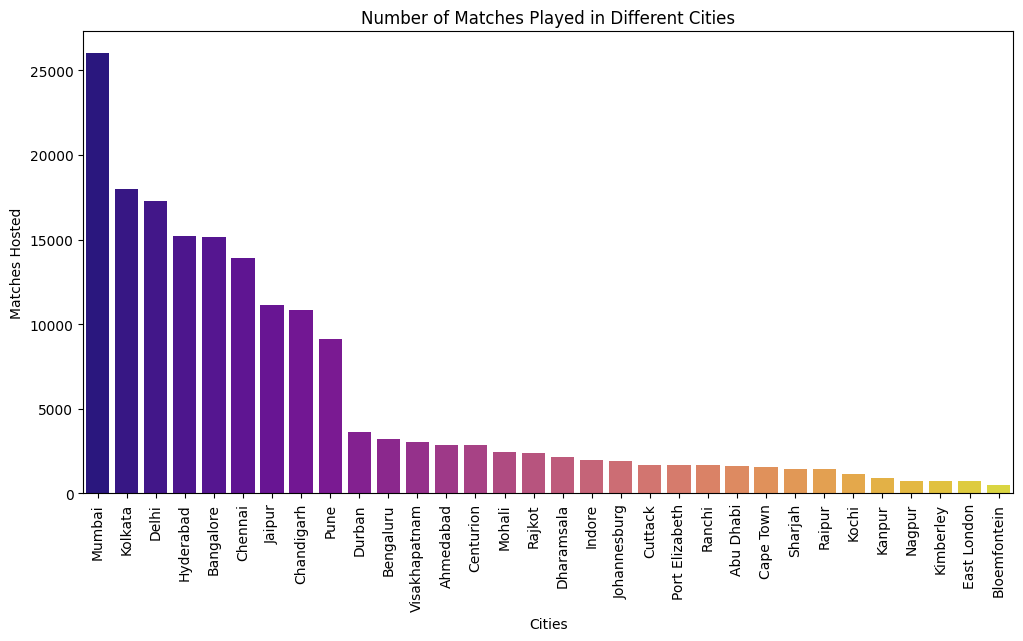

In [21]:
#Matches Played in Different Cities
city_matches = merged_df['city'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=city_matches.index, y=city_matches.values, palette='plasma')
plt.xticks(rotation=90)
plt.xlabel("Cities")
plt.ylabel("Matches Hosted")
plt.title("Number of Matches Played in Different Cities")
plt.show()
